In [1]:
import pandas as pd

df = pd.read_csv('filtered_NFR.csv')
df.shape

(16262, 12)

In [2]:
df.isnull().sum()

Time                  0
Site Name             0
Point Machine Name    0
Direction             0
A Current             0
A Voltage             0
B Current             0
B Voltage             0
Type of A             0
Type of B             0
Polling of A          0
Polling of B          0
dtype: int64

In [3]:
max_len = df["A Current"].apply(lambda x: len(x.split(","))).max()
print("Longest signal length:", max_len)

Longest signal length: 580


In [4]:
import matplotlib.pyplot as plt

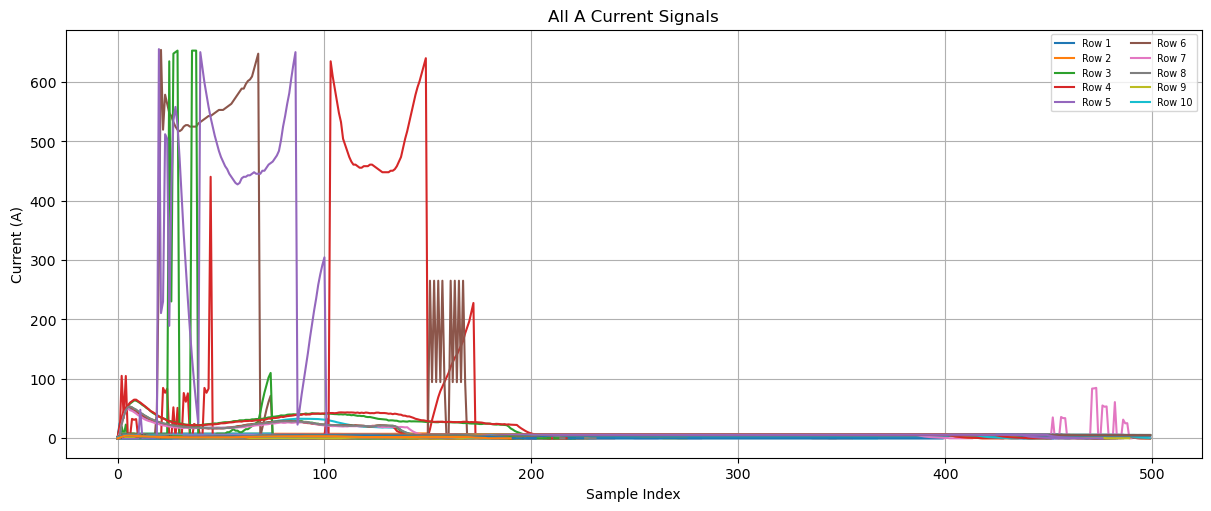

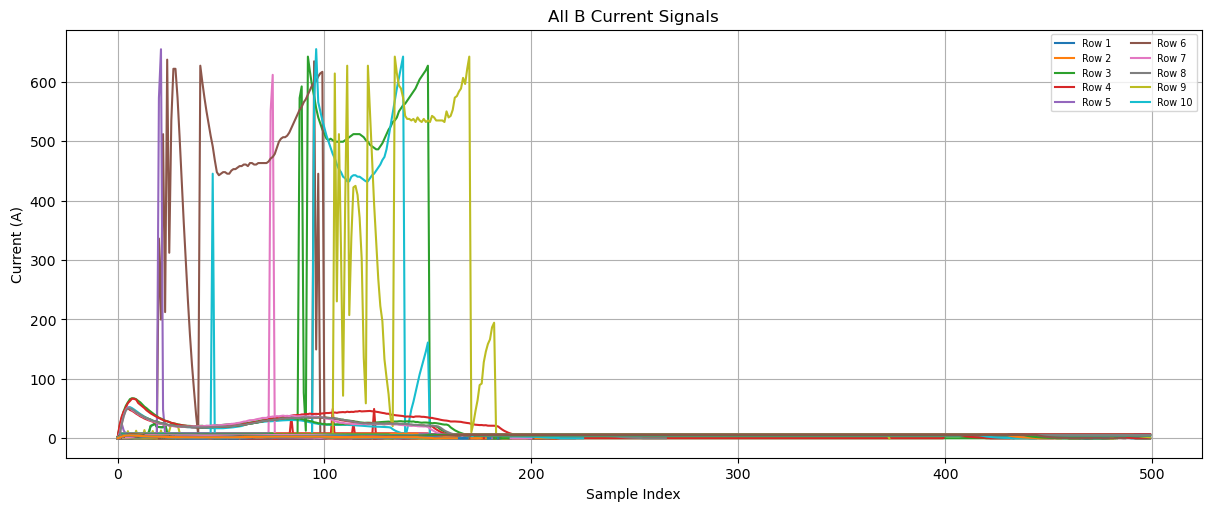

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import warnings

# Suppress specific UserWarnings
warnings.filterwarnings("ignore", message=".*Creating legend with loc=.*")
warnings.filterwarnings("ignore", message=".*Tight layout not applied.*")

# Convert string to float list
def parse_signal(signal_str):
    return [float(x.strip()) for x in signal_str.split(",")]

# Clip signal to first 210 samples
def clip_signal(signal, max_len=500):
    return signal[:max_len]

# ---- Plot all A Currents ----
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
for i, row in df.iterrows():
    signal = clip_signal(parse_signal(row["A Current"]))
    ax.plot(signal, label=f'Row {i+1}')
ax.set_title("All A Current Signals")
ax.set_xlabel("Sample Index")
ax.set_ylabel("Current (A)")
ax.grid(True)
# Show only up to 10 legends
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:10], labels[:10], fontsize='x-small', ncol=2, loc='upper right')

plt.show()

# ---- Plot all B Currents ----
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
for i, row in df.iterrows():
    signal = clip_signal(parse_signal(row["B Current"]))
    ax.plot(signal, label=f'Row {i+1}')
ax.set_title("All B Current Signals")
ax.set_xlabel("Sample Index")
ax.set_ylabel("Current (A)")
ax.grid(True)
# Show only up to 10 legends
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:10], labels[:10], fontsize='x-small', ncol=2, loc='upper right')

plt.show()



In [11]:
def parse_signal(signal_str):
    return [float(x.strip()) for x in signal_str.split(",")]

def is_valid_signal(signal, max_len=210, max_amplitude=100):
    clipped = signal[:max_len]
    return all(val <= max_amplitude for val in clipped)

# Filter the DataFrame based on A Current signal
filtered_df = df[df["A Current"].apply(lambda s: is_valid_signal(parse_signal(s)))].reset_index(drop=True)


In [12]:
filtered_df.shape

(16256, 12)

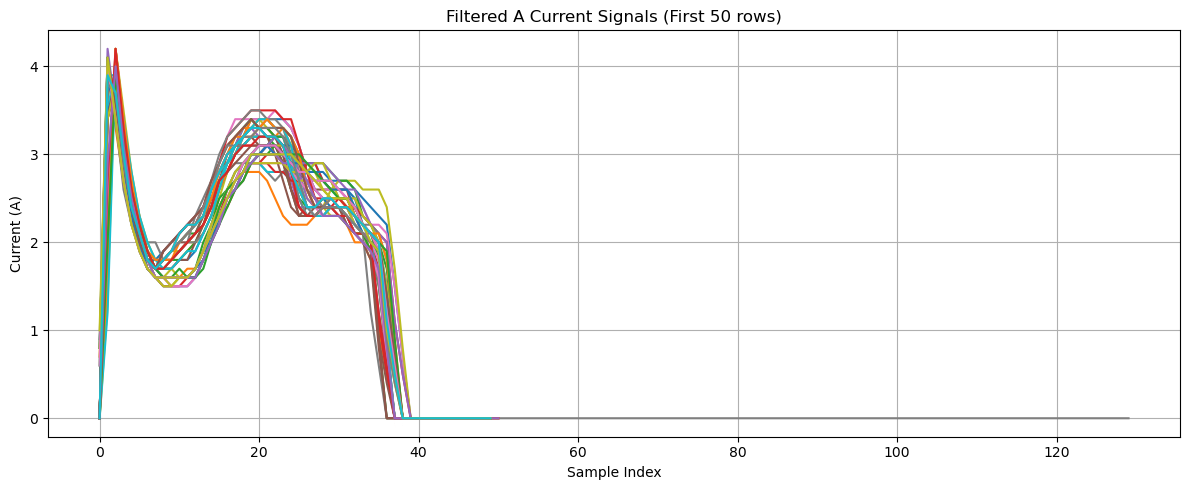

In [14]:
N = 50  # or any manageable number
subset = filtered_df.iloc[:N]

plt.figure(figsize=(12, 5))
for i, row in subset.iterrows():
    signal = parse_signal(row["A Current"])[:210]
    plt.plot(signal, label=f'Row {i+1}')
plt.title("Filtered A Current Signals (First 50 rows)")
plt.xlabel("Sample Index")
plt.ylabel("Current (A)")
plt.grid(True)
# plt.legend(fontsize='x-small', ncol=2, loc='upper right')
plt.tight_layout()
plt.show()

In [25]:
def parse_signal(signal_str):
    return [float(x.strip()) for x in signal_str.split(",")]

def is_good_signal(signal, max_len=60, max_value=5.0, flat_threshold=10):
    clipped = signal[:max_len]

    # Rule 1: All values should be <= max_value
    if any(val > max_value for val in clipped):
        return False

    # Rule 2: No long flat segments at high value
    # Detect if 5+ consecutive values are nearly the same above a threshold
    flat_count = 0
    for i in range(1, len(clipped)):
        if abs(clipped[i] - clipped[i-1]) < 0.01 and clipped[i] > 4.8:
            flat_count += 1
            if flat_count >= flat_threshold:
                return False
        else:
            flat_count = 0

    # Rule 3: Optional: Length should not exceed max_len (already clipped)
    return True

# Apply on your DataFrame
good_rows = []
bad_rows = []

for _, row in df.iterrows():
    signal = parse_signal(row["A Current"])
    if is_good_signal(signal):
        good_rows.append(row)
    else:
        bad_rows.append(row)

# Create new DataFrames
df_good = pd.DataFrame(good_rows).reset_index(drop=True)
df_bad = pd.DataFrame(bad_rows).reset_index(drop=True)
df_good.shape, df_bad.shape

((13279, 12), (2983, 12))

In [20]:
good_rows = []
bad_rows = []

for _, row in df.iterrows():
    signal = parse_signal(row["A Current"])
    if is_good_signal(signal):
        good_rows.append(row)
    else:
        bad_rows.append(row)

df_good = pd.DataFrame(good_rows).reset_index(drop=True)
df_bad = pd.DataFrame(bad_rows).reset_index(drop=True)


In [17]:
# Save results as CSV files
df_good.to_csv("good_signals.csv", index=False)
df_bad.to_csv("bad_signals.csv", index=False)

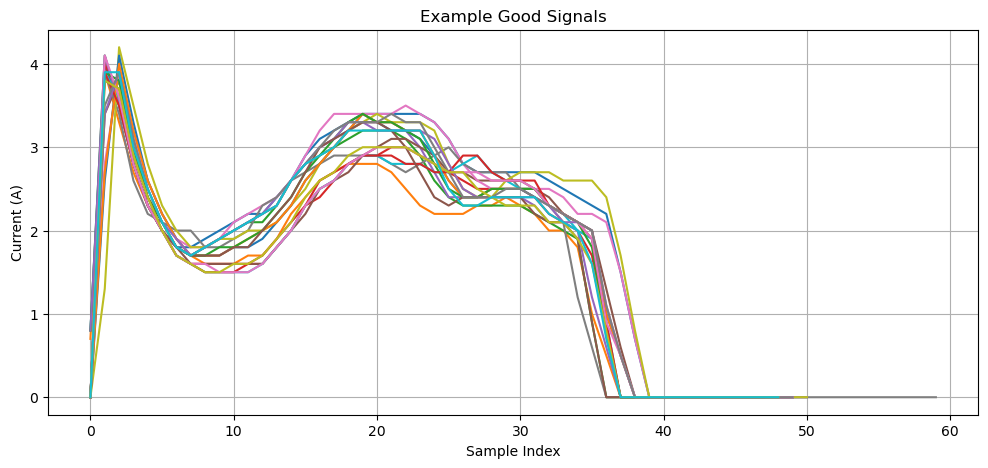

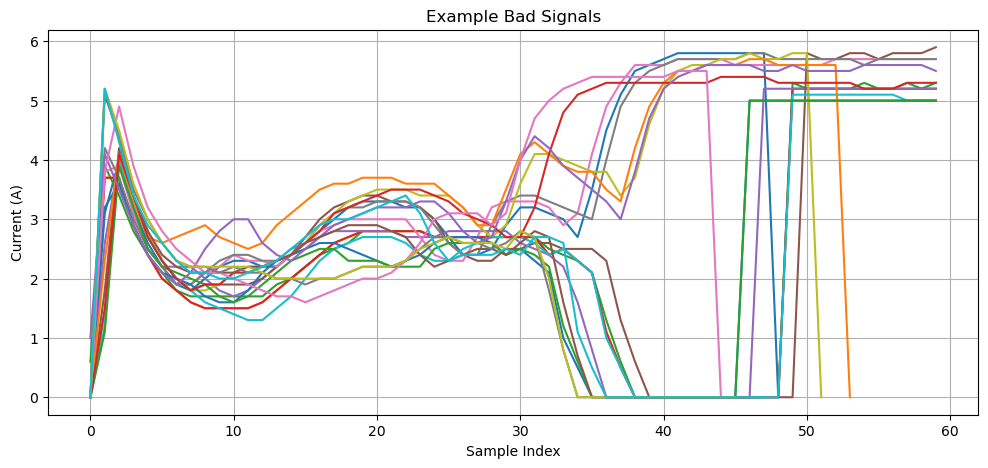

In [27]:

# Quick visualization
import matplotlib.pyplot as plt

def plot_signals(df, title):
    plt.figure(figsize=(12, 5))
    for _, row in df.iterrows():
        signal = parse_signal(row["A Current"])[:60]
        plt.plot(signal)
    plt.title(title)
    plt.xlabel("Sample Index")
    plt.ylabel("Current (A)")
    plt.grid(True)
    plt.show()

plot_signals(df_good.head(20), "Example Good Signals")
plot_signals(df_bad.head(20), "Example Bad Signals")